# OOD Detection with GSVD experiment notebook

This notebook combines five ablation experiments for detecting out-of-distribution (OOD) images using the Generalized Singular Value Decomposition (GSVD) between an expert and a novice feature extractor.

### The idea

A strong pretrained model (expert) and a randomly initialized model (novice) produce different feature behavior on ID vs OOD images. On in-distribution scenes the expert features are more structured, while on OOD scenes that structure weakens and GSVD ratios shift.

### Setup

| piece | what was used |
| --- | --- |
| Expert | DINOv3 ViT-B/16 (pretrained, frozen) |
| Novice | Random-init SegFormer-B5 or simpler CNN |
| ID data | Cityscapes val (Tuebingen, Ulm, Weimar, Zurich) |
| OOD data | Fishyscapes + AnomalyTrack |
| Domain-shift control | BDD100K (real-world shift, no anomalies) |

### The five experiments

1. Exp 1: How to aggregate GSVD ratios into one score? (mean / median / max)
2. Exp 2: Does the novice need to be complex, or is a tiny CNN enough?
3. Exp 3: How many GSVD ratios are actually needed?
4. Exp 4: Does it still work with a pretrained SegFormer as expert (instead of DINOv3)?
5. Exp 5: Is the score detecting anomalies, or mostly distribution shift / brightness?


## 1. Imports


In [1]:
import os, glob, csv, random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageOps
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.auto import tqdm
import pandas as pd

import timm
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torchvision.transforms.v2 import (
    Compose, ToImage, Resize, ToDtype, Normalize, InterpolationMode,
)


# Set up matplotlib parameters for plotting
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

## 2. Paths and global config

If we move the data or the weights somewhere else, this is the only cell we need to edit.


In [2]:
# Project root
# I first broke this by running from the wrong cwd, so keep BASE explicit.
BASE = "/Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz"

# Model weights
DINO_WEIGHTS      = f"{BASE}/weights/dinov3_vitb16_timm.pth"
SEGFORMER_WEIGHTS = f"{BASE}/weights/segformer.pt"

# Dataset paths
CITYSCAPES_VAL = f"{BASE}/datasets/ID data/cityscapes/leftImg8bit/val"
BDD_DIR        = f"{BASE}/datasets/ID data/bdd100k_500"
ANOMALY_DIR    = f"{BASE}/datasets/OOD data/dataset_AnomalyTrack/images"
FISHY_DIR      = f"{BASE}/datasets/OOD data/fishyscapes_rgb_100"

# I only use the validation set of Cityscapes for ID data
ID_FOLDERS = [
    f"{CITYSCAPES_VAL}/tubingen",
    f"{CITYSCAPES_VAL}/ulm",
    f"{CITYSCAPES_VAL}/weimar",
    f"{CITYSCAPES_VAL}/zurich",
]
OOD_FOLDERS     = [FISHY_DIR, ANOMALY_DIR]
DS_REAL_FOLDERS = [BDD_DIR]

# Experiments config
SEED       = 1
INPUT_SIZE = (512, 512)
# I got a CPU/GPU mismatch error before; keep tensors and model on DEVICE.
DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Using device:", DEVICE)

# Where CSVs and plots go
RESULTS_ROOT = "results"
os.makedirs(RESULTS_ROOT, exist_ok=True)

Using device: mps


### Quick path sanity check


In [3]:
# This loop can take a while; when debugging I run on a tiny subset first.
for p in [DINO_WEIGHTS, SEGFORMER_WEIGHTS, *ID_FOLDERS, *OOD_FOLDERS, *DS_REAL_FOLDERS]:
    print(("ok  " if os.path.exists(p) else "MISS"), p)

ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/weights/dinov3_vitb16_timm.pth
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/weights/segformer.pt
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/tubingen
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/ulm
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/weimar
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/zurich
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/OOD data/fishyscapes_rgb_100
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vi

## 3. Seeding

Because the novice is randomly initialized, the score for each image depends on that random init. For reproducibility, it is seeded.


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 4. GSVD algorithm


In [5]:
def gsvd0(A: np.ndarray, B: np.ndarray):

    """Compute the generalized singular value decomposition (GSVD) of two matrices A and B.
    where A and B have the same number of columns. In this formula there can be less rows than columns.
    Adapted from code by Michiel Hochstenbach, TU/e.
    """
    A = np.asarray(A, dtype=np.float64)     #
    B = np.asarray(B, dtype=np.float64)
    M = np.vstack([A, B])
    Q, R = np.linalg.qr(M, mode="reduced")
    m1 = A.shape[0]
    Q1, Q2 = Q[:m1, :], Q[m1:, :]
    U, c, Wt = np.linalg.svd(Q1, full_matrices=False)
    W = Wt.T
    s = np.sqrt(np.maximum(1.0 - c ** 2, 0.0))
    Q2W = Q2 @ W
    V = np.zeros_like(Q2W)
    # This loop can take a while; when debugging I run on a tiny subset first.
    for i in range(Q2W.shape[1]):
        nrm = np.linalg.norm(Q2W[:, i])
        if nrm > 1e-14:
            V[:, i] = Q2W[:, i] / nrm
    X = R.T @ W
    return U, V, X, c, s

### Sanity check
For any valid GSVD the identity `c² + s² = 1` should hold.


In [6]:
np.random.seed(0)
A_test = np.random.randn(100, 50)
B_test = np.random.randn(200, 50)
_, _, _, c, s = gsvd0(A_test, B_test)
print("max |c^2 + s^2 - 1| =", np.max(np.abs(c**2 + s**2 - 1)))

max |c^2 + s^2 - 1| = 2.220446049250313e-16


## 5. Shared helpers

Things every experiment uses: collect image paths, a standard preprocessing transform, and a classification-metrics evaluator.


In [7]:
# Paths to all images in the ID and OOD folders
def collect_image_paths(folders):
    paths = []
    # This loop can take a while; when debugging I run on a tiny subset first.
    for folder in folders:
        paths += sorted(glob.glob(os.path.join(folder, "*.png")))
        paths += sorted(glob.glob(os.path.join(folder, "*.jpg")))
    return paths

# Standard preprocessing images
# Resize + normalize must match training setup, otherwise scores drift a lot.
preprocess = Compose([
    ToImage(),
    Resize(size=INPUT_SIZE, interpolation=InterpolationMode.BILINEAR),
    ToDtype(dtype=torch.float32, scale=True),
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Find threshold maximizing accuracy
def find_optimal_threshold(id_scores, ood_scores):
    """Brute-force sweep thresholds to maximize accuracy. Returns (threshold, accuracy, (tp, fp, fn, tn))."""
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    sorted_s = np.sort(np.unique(scores))
    candidates = (sorted_s[:-1] + sorted_s[1:]) / 2
    best_acc, best_t, best_cm = 0.0, 0.0, (0, 0, 0, 0)
    for t in candidates:
        preds = (scores > t).astype(int)
        acc = (preds == labels).mean()
        if acc > best_acc:
            best_acc, best_t = acc, t
            tp = int(((preds == 1) & (labels == 1)).sum())
            fp = int(((preds == 1) & (labels == 0)).sum())
            fn = int(((preds == 0) & (labels == 1)).sum())
            tn = int(((preds == 0) & (labels == 0)).sum())
            best_cm = (tp, fp, fn, tn)
    return best_t, best_acc, best_cm

# Evaluation
def evaluate(id_vals, ood_vals):
    """Full classification metrics for a pair of score arrays."""
    id_vals  = np.asarray(id_vals);  id_vals  = id_vals[np.isfinite(id_vals)]
    ood_vals = np.asarray(ood_vals); ood_vals = ood_vals[np.isfinite(ood_vals)]
    thresh, acc, (tp, fp, fn, tn) = find_optimal_threshold(id_vals, ood_vals)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    labels = np.concatenate([np.zeros(len(id_vals)), np.ones(len(ood_vals))])
    scores = np.concatenate([id_vals, ood_vals])
    auroc = roc_auc_score(labels, scores)
    return dict(threshold=float(thresh), accuracy=float(acc),
                precision=float(prec), recall=float(rec), f1=float(f1),
                auroc=float(auroc), tp=tp, fp=fp, fn=fn, tn=tn)

## 6. Models

### Expert: DINOv3 ViT-B/16

### Novices (three variants for Exp 2)
All three output `(1, 320, 32, 32)` so compareable

### Alternative expert (Exp 4)
`SegFormerExpert` pretrained on Cityscapes


In [8]:
class DinoExpert(nn.Module):
    """Frozen DINOv3. Returns patch tokens on a grid of size target_size."""
    def __init__(self, weights_path=DINO_WEIGHTS):
        super().__init__()
        self.dino = timm.create_model(
            "vit_base_patch16_dinov3.lvd1689m",
            pretrained=False, num_classes=0,
        )
        state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
        if "model" in state_dict:
            state_dict = state_dict["model"]
        self.dino.load_state_dict(state_dict, strict=True)
        self.dino.eval()
        # This loop can take a while; when debugging I run on a tiny subset first.
        for p in self.dino.parameters():
            p.requires_grad_(False)

    def forward(self, x, target_size=None):
        out = self.dino.forward_features(x)
        tokens = out[:, 5:, :]                    # skip 4 registers + 1 CLS
        N = tokens.shape[1]
        h = w = int(N ** 0.5)
        grid = tokens.permute(0, 2, 1).reshape(x.shape[0], 768, h, w)
        if target_size is not None:
            grid = F.interpolate(grid, size=target_size,
                                 mode="bilinear", align_corners=False)
        return grid  # (B, 768, H, W)

In [9]:
FEAT_SIZE = (32, 32)   # 512 / 16
FEAT_DIM  = 320        # matches SegFormer hidden_states[2]

class LinearNovice(nn.Module):
    """1x1 conv projection + bilinear downsample. ~960 params."""
    def __init__(self, in_channels=3, feat_dim=FEAT_DIM):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, feat_dim, kernel_size=1, bias=False)
    def forward(self, x):
        out = self.proj(x)
        return F.interpolate(out, size=FEAT_SIZE, mode="bilinear", align_corners=False)

class NonlinearNovice(nn.Module):
    """4 stride-2 conv+BN+ReLU blocks (3→64→128→256→320). ~1.2M params."""
    def __init__(self, in_channels=3, feat_dim=FEAT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, feat_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(feat_dim), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

def _segformer_b5_config(n_classes=19):
    """Shared SegFormer-B5 config used for both random-init novice and pretrained expert."""
    return SegformerConfig(
        num_channels=3, num_labels=n_classes,
        num_encoder_blocks=4, depths=[3, 6, 40, 3],
        sr_ratios=[8, 4, 2, 1], hidden_sizes=[64, 128, 320, 512],
        num_attention_heads=[1, 2, 5, 8], mlp_ratios=[4, 4, 4, 4],
        hidden_act="gelu", hidden_dropout_prob=0.0,
        attention_probs_dropout_prob=0.0, classifier_dropout_prob=0.1,
        decoder_hidden_size=768, semantic_loss_ignore_index=255,
    )

class SegFormerNovice(nn.Module):
    """Random-init SegFormer-B5. ~84M params.
    Returns hidden_states[2] → (1, 320, 32, 32)."""
    def __init__(self):
        super().__init__()
        self.segformer = SegformerForSemanticSegmentation(_segformer_b5_config())
    def forward(self, x):
        out = self.segformer(pixel_values=x, output_hidden_states=True)
        return out.hidden_states[2]

class SegFormerExpert(nn.Module):
    """Pretrained SegFormer-B5 (Cityscapes). Returns hidden_states[2]."""
    def __init__(self, weights_path=SEGFORMER_WEIGHTS):
        super().__init__()
        self.segformer = SegformerForSemanticSegmentation(_segformer_b5_config())
        sd = torch.load(weights_path, map_location="cpu", weights_only=True)
        sd = {k: v for k, v in sd.items() if not k.startswith("ood_")}  # drop wrapper keys
        missing, unexpected = self.segformer.load_state_dict(sd, strict=False)
        print(f"SegFormer expert loaded: "
              f"{len(sd) - len(unexpected)}/{len(sd)} keys used, "
              f"{len(missing)} missing, {len(unexpected)} unexpected")
        self.segformer.eval()
        # This loop can take a while; when debugging I run on a tiny subset first.
        for p in self.segformer.parameters():
            p.requires_grad_(False)
    def forward(self, x):
        out = self.segformer(pixel_values=x, output_hidden_states=True)
        return out.hidden_states[2]

### The GSVD scoring pipeline
This is the part every experiment calls per image: given novice features `A` and expert features `B`, compute the generalized singular value ratios and aggregate.

In [10]:
def compute_gsvd_ratios(A_feat, B_feat, start_idx, n_ratios):
    """Run GSVD between two feature tensors and return n_ratios ratios starting at start_idx."""
    A = A_feat.squeeze(0).flatten(1).T       # (HW, C_A)
    B = B_feat.squeeze(0).flatten(1).T       # (HW, C_B)
    A_norm = F.normalize(A, dim=1).T.cpu().numpy()   # (C_A, HW)
    B_norm = F.normalize(B, dim=1).T.cpu().numpy()   # (C_B, HW)
    _, _, _, C, S = gsvd0(A_norm, B_norm)
    gen_sv = C / S
    return gen_sv[start_idx : start_idx + n_ratios]

def aggregate(ratios, metric):
    finite = ratios[np.isfinite(ratios)]
    if len(finite) == 0:
        return None
    if metric == "mean":   return float(finite.mean())
    if metric == "median": return float(np.median(finite))
    if metric == "max":    return float(finite.max())
    raise ValueError(metric)

## Experiment 0: Entropy baseline
Before jumping into the GSVD stuff I want a simple baseline I can actually compare against. The most obvious one: the pretrained SegFormer already outputs per-pixel class probabilities, so I just compute the mean pixel entropy of the softmax. 

In [11]:
EXP0_DIR = os.path.join(RESULTS_ROOT, "exp0_entropy_baseline")
os.makedirs(EXP0_DIR, exist_ok=True)
EXP0_CSV = os.path.join(EXP0_DIR, "entropy_scores.csv")

def entropy_score(model, img):
    """Mean per-pixel entropy of the softmax over class logits."""
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model.segformer(pixel_values=x).logits.float()   # (1, C, h, w)
    probs = torch.softmax(logits, dim=1)
    ent = -(probs * torch.log(probs + 1e-8)).sum(dim=1).mean()
    return float(ent.item())

def run_exp0(force=False):
    if not force and os.path.exists(EXP0_CSV):
        print(f"Loading cached {EXP0_CSV}")
        return pd.read_csv(EXP0_CSV).to_dict("records")

    model = SegFormerExpert().to(DEVICE).eval()

    records = []
    # This loop can take a while; when debugging I run on a tiny subset first.
    for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
        paths = collect_image_paths(folders)
        print(f"{label}: {len(paths)} images")
        for path in tqdm(paths, desc=label):
            try:
                img = Image.open(path).convert("RGB")
                records.append({
                    "label":    label,
                    "filename": os.path.basename(path),
                    "entropy":  entropy_score(model, img),
                })
            except Exception as e:
                print(f"FAIL {os.path.basename(path)}: {e}")

    pd.DataFrame(records).to_csv(EXP0_CSV, index=False)
    print(f"Saved -> {EXP0_CSV}")

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records

records_e0 = run_exp0()
print(f"Total records: {len(records_e0)}")


Loading cached results/exp0_entropy_baseline/entropy_scores.csv
Total records: 713


Method         Acc   AUROC    Prec  Recall      F1    Thresh
entropy     77.1%  68.6%  94.3%  23.8%  38.0%    0.1585


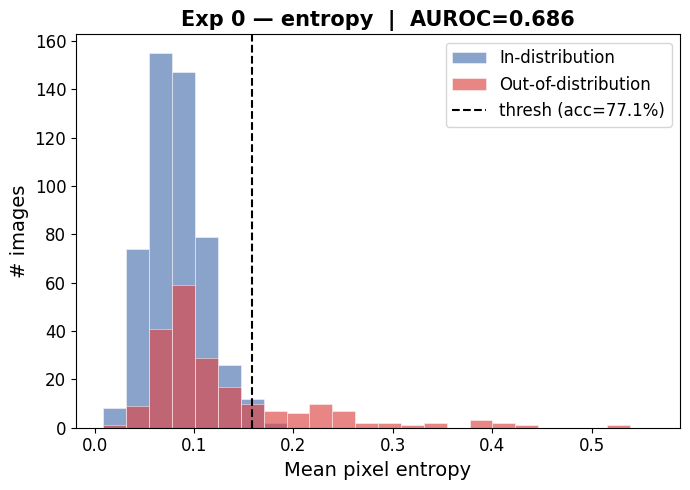

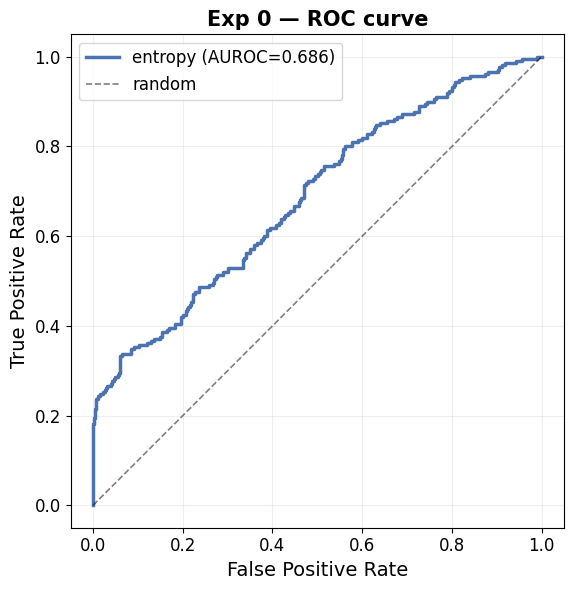

In [12]:
id_vals_e0  = np.array([r["entropy"] for r in records_e0 if r["label"] == "ID"])
ood_vals_e0 = np.array([r["entropy"] for r in records_e0 if r["label"] == "OOD"])

res_e0 = evaluate(id_vals_e0, ood_vals_e0)

print(f"{'Method':<10} {'Acc':>7} {'AUROC':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Thresh':>9}")
print(f"{'entropy':<10} {res_e0['accuracy']:>6.1%} {res_e0['auroc']:>6.1%} "
      f"{res_e0['precision']:>6.1%} {res_e0['recall']:>6.1%} {res_e0['f1']:>6.1%} {res_e0['threshold']:>9.4f}")
pd.DataFrame([res_e0]).to_csv(os.path.join(EXP0_DIR, "entropy_summary.csv"), index=False)

# Histogram
fig1, ax1 = plt.subplots(figsize=(7, 5))
lo = min(id_vals_e0.min(), ood_vals_e0.min()) * 0.95
hi = max(id_vals_e0.max(), ood_vals_e0.max()) * 1.05
bins = np.linspace(lo, hi, 25)
ax1.hist(id_vals_e0,  bins=bins, alpha=0.65, color="#4C72B0",
         label="In-distribution",    edgecolor="white", linewidth=0.5)
ax1.hist(ood_vals_e0, bins=bins, alpha=0.65, color="#DD4444",
         label="Out-of-distribution", edgecolor="white", linewidth=0.5)
ax1.axvline(res_e0["threshold"], color="black", linestyle="--", linewidth=1.5,
            label=f"thresh (acc={res_e0['accuracy']:.1%})")
ax1.set_xlabel("Mean pixel entropy", fontsize=14)
ax1.set_ylabel("# images", fontsize=14)
ax1.set_title(f"Exp 0 — entropy  |  AUROC={res_e0['auroc']:.3f}", fontweight="bold", fontsize=15)
ax1.legend(fontsize=12)
ax1.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(EXP0_DIR, "entropy_histogram.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# ROC curve
fig2, ax2 = plt.subplots(figsize=(6, 6))
labels_e0 = np.concatenate([np.zeros(len(id_vals_e0)), np.ones(len(ood_vals_e0))])
scores_e0 = np.concatenate([id_vals_e0, ood_vals_e0])
# Easy to forget: ROC assumes positive class = 1, so labels must be set consistently.
fpr, tpr, _ = roc_curve(labels_e0, scores_e0)
ax2.plot(fpr, tpr, color="#4C72B0", linewidth=2.5,
         label=f"entropy (AUROC={res_e0['auroc']:.3f})")
ax2.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1.2, label="random")
ax2.set_xlabel("False Positive Rate", fontsize=14)
ax2.set_ylabel("True Positive Rate", fontsize=14)
ax2.set_title("Exp 0 — ROC curve", fontweight="bold", fontsize=15)
ax2.legend(fontsize=12)
ax2.set_aspect("equal")
ax2.grid(alpha=0.2)
ax2.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(EXP0_DIR, "entropy_roc.pdf"), dpi=300, bbox_inches="tight")
plt.show()

## Experiment 1: Which aggregation metric?

- mean: sensitive to outliers
- median: robust to outliers
- max: picks the single worst direction

we use `SegFormerNovice` (random-init) + `DinoExpert` here.

In [13]:
EXP1_DIR = os.path.join(RESULTS_ROOT, "exp1_metric")
os.makedirs(EXP1_DIR, exist_ok=True)
EXP1_CSV = os.path.join(EXP1_DIR, "metric_comparison.csv")

N_RATIOS_E1  = 64 # All ratios
START_IDX_E1 = 256
METRICS      = ["mean", "median", "max"]

def run_exp1(force=False):
    """Runs inference for Exp 1 (or loads the cached CSV). Returns list of records."""
    if not force and os.path.exists(EXP1_CSV):
        print(f"Loading cached results from {EXP1_CSV}")
        return pd.read_csv(EXP1_CSV).to_dict("records")

    set_seed(SEED)
    novice = SegFormerNovice().to(DEVICE).eval()
    expert = DinoExpert().to(DEVICE).eval()

    records = []
    # This loop can take a while; when debugging I run on a tiny subset first.
    for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
        paths = collect_image_paths(folders)
        print(f"{label}: {len(paths)} images")
        for path in tqdm(paths, desc=label):
            try:
                img = Image.open(path).convert("RGB")
                x = preprocess(img).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    A_feat = novice(x)
                    B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
                ratios = compute_gsvd_ratios(A_feat, B_feat, START_IDX_E1, N_RATIOS_E1)
                finite = ratios[np.isfinite(ratios)]
                if len(finite) == 0:
                    continue
                records.append({
                    "label":    label,
                    "filename": os.path.basename(path),
                    "mean":     float(finite.mean()),
                    "median":   float(np.median(finite)),
                    "max":      float(finite.max()),
                })
            except Exception as e:
                print(f"FAIL {os.path.basename(path)}: {e}")

    with open(EXP1_CSV, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["label", "filename", "mean", "median", "max"])
        w.writeheader()
        w.writerows(records)
    print(f"Saved -> {EXP1_CSV}")

    del novice, expert
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records

records_e1 = run_exp1()
print(f"Total records: {len(records_e1)}")

Loading cached results from results/exp1_metric/metric_comparison.csv
Total records: 713


### Evaluate each metric


In [14]:
id_recs_e1  = [r for r in records_e1 if r["label"] == "ID"]
ood_recs_e1 = [r for r in records_e1 if r["label"] == "OOD"]

summary_e1 = []
# This loop can take a while; when debugging I run on a tiny subset first.
for metric in METRICS:
    id_vals  = np.array([r[metric] for r in id_recs_e1])
    ood_vals = np.array([r[metric] for r in ood_recs_e1])
    res = evaluate(id_vals, ood_vals)
    res["metric"] = metric
    summary_e1.append(res)

print(f"{'Metric':<8} {'Acc':>7} {'AUROC':>7} {'Prec':>7} {'Recall':>7} {'F1':>7}")
for r in summary_e1:
    print(f"{r['metric']:<8} {r['accuracy']:>6.1%} {r['auroc']:>6.1%} "
          f"{r['precision']:>6.1%} {r['recall']:>6.1%} {r['f1']:>6.1%}")

pd.DataFrame(summary_e1).to_csv(os.path.join(EXP1_DIR, "metric_summary.csv"), index=False)

Metric       Acc   AUROC    Prec  Recall      F1
mean      85.4%  91.2%  78.2%  70.0%  73.9%
median    86.4%  92.6%  76.5%  77.6%  77.1%
max       84.4%  89.9%  74.4%  71.9%  73.1%


### Plots, histograms and ROC curves


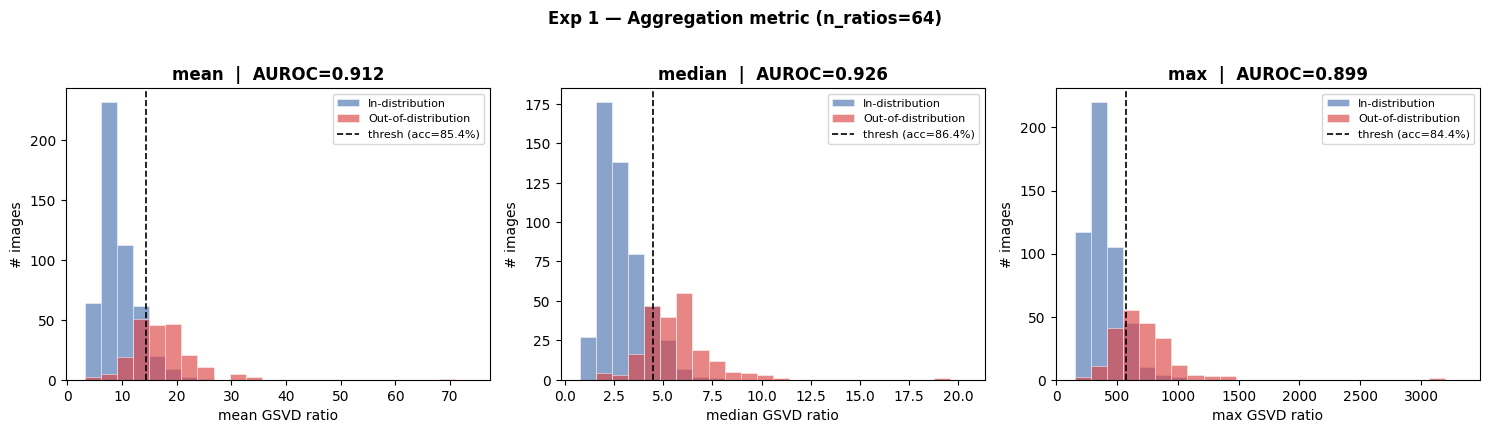

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
# This loop can take a while; when debugging I run on a tiny subset first.
for ax, metric in zip(axes, METRICS):
    id_vals  = np.array([r[metric] for r in id_recs_e1])
    ood_vals = np.array([r[metric] for r in ood_recs_e1])
    row = next(r for r in summary_e1 if r["metric"] == metric)
    lo = min(id_vals.min(), ood_vals.min()) * 0.95
    hi = max(id_vals.max(), ood_vals.max()) * 1.05
    bins = np.linspace(lo, hi, 25)
    ax.hist(id_vals,  bins=bins, alpha=0.65, color="#4C72B0",
            label="In-distribution",    edgecolor="white", linewidth=0.5)
    ax.hist(ood_vals, bins=bins, alpha=0.65, color="#DD4444",
            label="Out-of-distribution", edgecolor="white", linewidth=0.5)
    ax.axvline(row["threshold"], color="black", linestyle="--", linewidth=1.2,
               label=f"thresh (acc={row['accuracy']:.1%})")
    ax.set_xlabel(f"{metric} GSVD ratio")
    ax.set_ylabel("# images")
    ax.set_title(f"{metric}  |  AUROC={row['auroc']:.3f}", fontweight="bold")
    ax.legend(fontsize=8)
fig.suptitle(f"Exp 1 — Aggregation metric (n_ratios={N_RATIOS_E1})",
             y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EXP1_DIR, "histogram.pdf"), dpi=300, bbox_inches="tight")
plt.show()

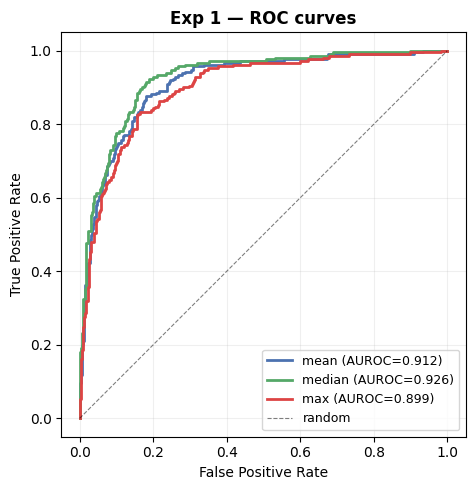

In [16]:
fig, ax = plt.subplots(figsize=(5.5, 5))
colors_e1 = {"mean": "#4C72B0", "median": "#55A868", "max": "#DD4444"}
# This loop can take a while; when debugging I run on a tiny subset first.
for metric in METRICS:
    id_vals  = np.array([r[metric] for r in id_recs_e1])
    ood_vals = np.array([r[metric] for r in ood_recs_e1])
    labels = np.concatenate([np.zeros(len(id_vals)), np.ones(len(ood_vals))])
    scores = np.concatenate([id_vals, ood_vals])
    # Easy to forget: ROC assumes positive class = 1, so labels must be set consistently.
    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = roc_auc_score(labels, scores)
    ax.plot(fpr, tpr, color=colors_e1[metric], linewidth=2,
            label=f"{metric} (AUROC={auroc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=0.8, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Exp 1 — ROC curves", fontweight="bold")
ax.legend(fontsize=9); ax.set_aspect("equal"); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(EXP1_DIR, "roc.pdf"), dpi=300, bbox_inches="tight")
plt.show()

Takeaway: median wins. It's the most robust to numerical fluctuations

## Experiments 2 + 3: Novice architecture + number of ratios

Then we just use that cached data for both experiments:
    Exp 2: Which novice architecture gives the best AUROC? (Using the median of all 64 ratios).

The novices we are comparing:
    Linear: Super simple 1x1 conv (only ~960 params).
    Nonlinear CNN: A basic 4-block CNN (~1.2M params).
    SegFormer-B5: The massive full encoder (~84M params).


In [17]:
EXP23_DIR = os.path.join(RESULTS_ROOT, "exp23_novice_nratios")
os.makedirs(EXP23_DIR, exist_ok=True)
EXP23_CSV = os.path.join(EXP23_DIR, "raw_ratios.csv")

NOVICE_CLASSES = {
    "Linear":         LinearNovice,
    "Nonlinear CNN":  NonlinearNovice,
    "SegFormer-B5":   SegFormerNovice,
}
MAX_RATIOS = 64   # number of GSVD ratios to save per image

def run_exp23(force=False):
    if not force and os.path.exists(EXP23_CSV):
        print(f"Loading cached {EXP23_CSV}")
        df = pd.read_csv(EXP23_CSV)
        ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
        return [{
            "novice":   row["novice"],
            "label":    row["label"],
            "filename": row["filename"],
            "ratios":   row[ratio_cols].to_numpy(dtype=float),
        } for _, row in df.iterrows()]

    expert = DinoExpert().to(DEVICE).eval()
    records = []

    # This loop can take a while; when debugging I run on a tiny subset first.
    for novice_name, NoviceCls in NOVICE_CLASSES.items():
        print(f"\n{'='*50}\n  {novice_name}\n{'='*50}")
        set_seed(SEED)
        novice = NoviceCls().to(DEVICE).eval()
        n_params = sum(p.numel() for p in novice.parameters())
        print(f"  Params: {n_params:,}")

        for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
            paths = collect_image_paths(folders)
            for path in tqdm(paths, desc=f"{novice_name} / {label}"):
                try:
                    img = Image.open(path).convert("RGB")
                    x = preprocess(img).unsqueeze(0).to(DEVICE)
                    with torch.no_grad():
                        A_feat = novice(x)
                        B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
                    ratios = compute_gsvd_ratios(A_feat, B_feat, 256, MAX_RATIOS)
                    records.append({
                        "novice":   novice_name,
                        "label":    label,
                        "filename": os.path.basename(path),
                        "ratios":   np.asarray(ratios, dtype=float),
                    })
                except Exception as e:
                    print(f"FAIL {os.path.basename(path)}: {e}")

        del novice
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    # save as wide CSV: one ratio per column
    with open(EXP23_CSV, "w", newline="") as f:
        w = csv.writer(f)
        header = ["novice", "label", "filename"] + [f"ratio_{i+1}" for i in range(MAX_RATIOS)]
        w.writerow(header)
        for r in records:
            w.writerow([r["novice"], r["label"], r["filename"]] +
                       [f"{v:.6f}" for v in r["ratios"]])
    print(f"Saved -> {EXP23_CSV}")

    del expert
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records

records_e23 = run_exp23()
print(f"Total records: {len(records_e23)}")

Loading cached results/exp23_novice_nratios/raw_ratios.csv
Total records: 2139


### Experiment 2: evaluate each novice at n_ratios = 64 (median)


In [18]:
summary_e2 = []
# This loop can take a while; when debugging I run on a tiny subset first.
for novice_name, NoviceCls in NOVICE_CLASSES.items():
    sub = [r for r in records_e23 if r["novice"] == novice_name]
    id_vals  = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "ID"],  dtype=float)
    ood_vals = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "OOD"], dtype=float)
    res = evaluate(id_vals, ood_vals)
    res["novice"] = novice_name
    # count params by building a fresh instance (tiny overhead, avoids keeping models in memory)
    set_seed(SEED)
    tmp = NoviceCls()
    res["params"] = int(sum(p.numel() for p in tmp.parameters()))
    del tmp
    summary_e2.append(res)

print(f"{'Novice':<16} {'Params':>12} {'Acc':>7} {'AUROC':>7} {'F1':>7}")
for r in summary_e2:
    print(f"{r['novice']:<16} {r['params']:>12,} "
          f"{r['accuracy']:>6.1%} {r['auroc']:>6.1%} {r['f1']:>6.1%}")

pd.DataFrame(summary_e2).to_csv(os.path.join(EXP23_DIR, "novice_summary.csv"), index=False)

Novice                 Params     Acc   AUROC      F1
Linear                    960  75.0%  63.0%  42.6%
Nonlinear CNN       1,109,952  88.6%  92.0%  79.5%
SegFormer-B5       84,607,955  86.4%  92.6%  77.1%


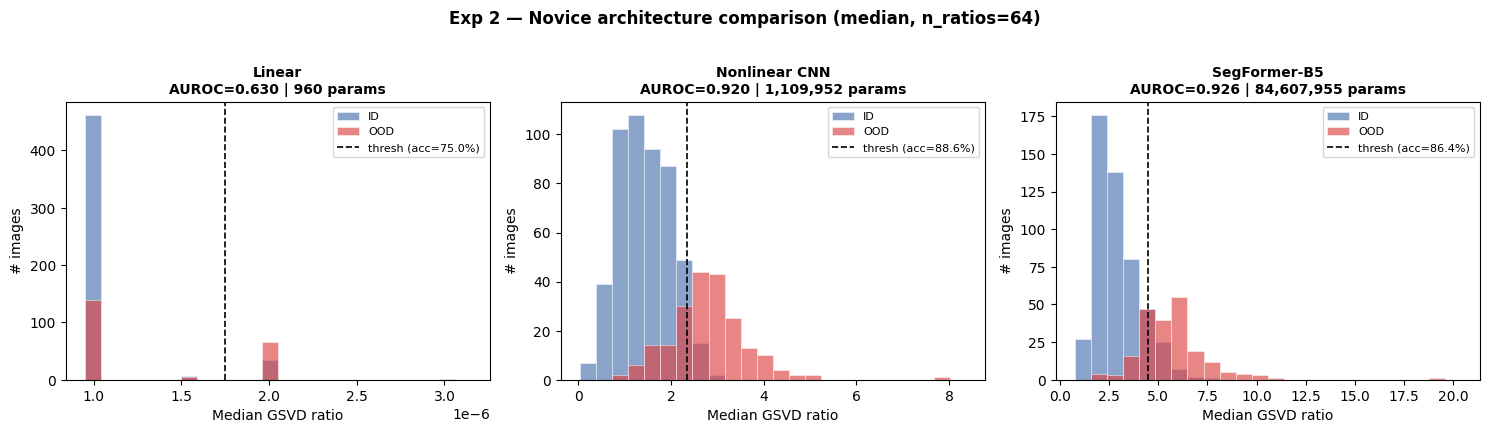

In [19]:
# Histograms per novice
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
# This loop can take a while; when debugging I run on a tiny subset first.
for ax, (novice_name, _NoviceCls) in zip(axes, NOVICE_CLASSES.items()):
    sub = [r for r in records_e23 if r["novice"] == novice_name]
    id_vals  = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "ID"],  dtype=float)
    ood_vals = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "OOD"], dtype=float)
    id_vals  = id_vals[np.isfinite(id_vals)]
    ood_vals = ood_vals[np.isfinite(ood_vals)]
    row = next(r for r in summary_e2 if r["novice"] == novice_name)
    lo = min(id_vals.min(), ood_vals.min()) * 0.95
    hi = max(id_vals.max(), ood_vals.max()) * 1.05
    bins = np.linspace(lo, hi, 25)
    ax.hist(id_vals,  bins=bins, alpha=0.65, color="#4C72B0", label="ID",  edgecolor="white", linewidth=0.5)
    ax.hist(ood_vals, bins=bins, alpha=0.65, color="#DD4444", label="OOD", edgecolor="white", linewidth=0.5)
    ax.axvline(row["threshold"], color="black", linestyle="--", linewidth=1.2,
               label=f"thresh (acc={row['accuracy']:.1%})")
    ax.set_xlabel("Median GSVD ratio")
    ax.set_ylabel("# images")
    ax.set_title(f"{novice_name}\nAUROC={row['auroc']:.3f} | {row['params']:,} params",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Exp 2 — Novice architecture comparison (median, n_ratios=64)",
             y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EXP23_DIR, "exp2_histograms.pdf"), dpi=300, bbox_inches="tight")
plt.show()

### Experiment 3: sweep n_ratios on the two best novices


In [20]:
N_RATIOS_LIST = [2, 5, 10, 15, 20, 25, 30, 40, 50, 64]
BEST_NOVICES  = ["Nonlinear CNN", "SegFormer-B5"]

sweep_rows = []
# This loop can take a while; when debugging I run on a tiny subset first.
for novice_name in BEST_NOVICES:
    sub = [r for r in records_e23 if r["novice"] == novice_name]
    for n in N_RATIOS_LIST:
        id_scores, ood_scores = [], []
        for r in sub:
            s = aggregate(r["ratios"][:n], "median")
            if s is None:
                continue
            (id_scores if r["label"] == "ID" else ood_scores).append(s)
        res = evaluate(np.asarray(id_scores), np.asarray(ood_scores))
        res["novice"]   = novice_name
        res["n_ratios"] = n
        sweep_rows.append(res)

sweep_df = pd.DataFrame(sweep_rows)[
    ["novice", "n_ratios", "accuracy", "auroc", "precision", "recall", "f1", "threshold"]
]
sweep_df.to_csv(os.path.join(EXP23_DIR, "nratios_sweep.csv"), index=False)
sweep_df

,novice,n_ratios,accuracy,auroc,precision,recall,f1,threshold
0,Nonlinear CNN,2,0.845722,0.897643,0.777778,0.666667,0.717949,200.188317
1,Nonlinear CNN,5,0.887798,0.941986,0.818627,0.795238,0.806763,7.537540
2,Nonlinear CNN,10,0.886396,0.942545,0.797235,0.823810,0.810304,6.499405
3,Nonlinear CNN,15,0.889201,0.942393,0.861878,0.742857,0.797954,6.058091
4,Nonlinear CNN,20,0.894811,0.940500,0.853403,0.776190,0.812968,5.438541
5,Nonlinear CNN,25,0.889201,0.939127,0.861878,0.742857,0.797954,5.035329
6,Nonlinear CNN,30,0.892006,0.940822,0.837563,0.785714,0.810811,4.461555
7,Nonlinear CNN,40,0.887798,0.936278,0.821782,0.790476,0.805825,3.693521
8,Nonlinear CNN,50,0.887798,0.931648,0.849462,0.752381,0.797980,3.110438
9,Nonlinear CNN,64,0.886396,0.919966,0.848649,0.747619,0.794937,2.350076


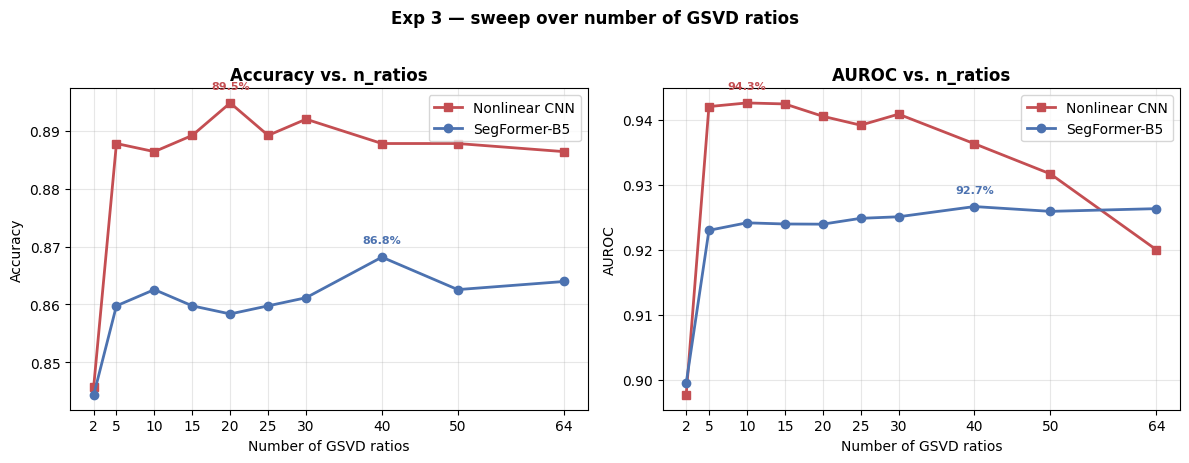

In [21]:
# Plot accuracy & AUROC vs n_ratios
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
style = {"Nonlinear CNN": dict(color="#C44E52", marker="s"),
         "SegFormer-B5":   dict(color="#4C72B0", marker="o")}
# This loop can take a while; when debugging I run on a tiny subset first.
for ax, key, ylabel in zip(axes, ["accuracy", "auroc"], ["Accuracy", "AUROC"]):
    for novice_name in BEST_NOVICES:
        rows = [r for r in sweep_rows if r["novice"] == novice_name]
        ns = [r["n_ratios"] for r in rows]
        vs = [r[key] for r in rows]
        ax.plot(ns, vs, linewidth=2, markersize=6, label=novice_name, **style[novice_name])
        best_idx = int(np.argmax(vs))
        ax.annotate(f"{vs[best_idx]:.1%}",
                    xy=(ns[best_idx], vs[best_idx]),
                    textcoords="offset points", xytext=(0, 10),
                    fontsize=8, ha="center", fontweight="bold",
                    color=style[novice_name]["color"])
    ax.set_xlabel("Number of GSVD ratios")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs. n_ratios", fontweight="bold")
    ax.set_xticks(N_RATIOS_LIST)
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Exp 3 — sweep over number of GSVD ratios", y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EXP23_DIR, "nratios_sweep.pdf"), dpi=300, bbox_inches="tight")
plt.show()

Takeaway from Exp 2 + 3:
- Linear novice is too simple, no nonlinearity means the score barely separates ID from OOD.
- Nonlinear CNN and SegFormer perform similarly, but the tiny CNN is way smaller in parameters.
- AUROC saturates quickly as `n_ratios` grows, adding more just injects noise from higher-index ratios.


## Experiment 4: What if the expert is a pretrained SegFormer instead of DINOv3?

Setup changes:
- Expert feature dim: 768 → 320 (SegFormer's `hidden_states[2]`).
- To keep a similar expert:novice dim ratio we drop the novice to 128-dim.


In [22]:
NOVICE_FEAT_DIM_E4 = 128

class NonlinearNoviceE4(nn.Module):
    """Slimmer CNN for Exp 4 — outputs 128-dim features."""
    def __init__(self, in_channels=3, feat_dim=NOVICE_FEAT_DIM_E4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 96, 3, stride=2, padding=1),
            nn.BatchNorm2d(96), nn.ReLU(inplace=True),
            nn.Conv2d(96, feat_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(feat_dim), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class SegFormerNoviceE4(nn.Module):
    """Random SegFormer novice that returns hidden_states[1] (128-dim)
    and downsamples to 32x32 to match the expert's spatial size."""
    def __init__(self):
        super().__init__()
        self.segformer = SegformerForSemanticSegmentation(_segformer_b5_config())
    def forward(self, x):
        out = self.segformer(pixel_values=x, output_hidden_states=True)
        feat = out.hidden_states[1]              # (1, 128, H/8, W/8)
        return F.interpolate(feat, size=FEAT_SIZE, mode="bilinear", align_corners=False)

In [23]:
EXP4_DIR = os.path.join(RESULTS_ROOT, "exp4_segformer_expert")
os.makedirs(EXP4_DIR, exist_ok=True)
EXP4_CSV = os.path.join(EXP4_DIR, "raw_ratios.csv")

START_IDX_E4  = 100
MAX_RATIOS_E4 = 28
N_RATIOS_LIST_E4 = [2, 5, 8, 10, 15, 20, 25, 28]

NOVICE_CLASSES_E4 = {
    "Nonlinear CNN":        NonlinearNoviceE4,
    "SegFormer-B5 (rand)":  SegFormerNoviceE4,
}

def run_exp4(force=False):
    if not force and os.path.exists(EXP4_CSV):
        print(f"Loading cached {EXP4_CSV}")
        df = pd.read_csv(EXP4_CSV)
        ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
        return [{
            "novice":   row["novice"],
            "label":    row["label"],
            "filename": row["filename"],
            "ratios":   row[ratio_cols].to_numpy(dtype=float),
        } for _, row in df.iterrows()]

    expert = SegFormerExpert().to(DEVICE).eval()
    records = []

    # This loop can take a while; when debugging I run on a tiny subset first.
    for novice_name, NoviceCls in NOVICE_CLASSES_E4.items():
        print(f"\n{'='*50}\n  {novice_name}\n{'='*50}")
        set_seed(SEED)
        novice = NoviceCls().to(DEVICE).eval()
        print(f"  Params: {sum(p.numel() for p in novice.parameters()):,}")

        for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
            paths = collect_image_paths(folders)
            for path in tqdm(paths, desc=f"{novice_name} / {label}"):
                try:
                    img = Image.open(path).convert("RGB")
                    x = preprocess(img).unsqueeze(0).to(DEVICE)
                    with torch.no_grad():
                        A_feat = novice(x)          # (1, 128, 32, 32)
                        B_feat = expert(x)          # (1, 320, 32, 32)
                    ratios = compute_gsvd_ratios(A_feat, B_feat, START_IDX_E4, MAX_RATIOS_E4)
                    records.append({
                        "novice":   novice_name,
                        "label":    label,
                        "filename": os.path.basename(path),
                        "ratios":   np.asarray(ratios, dtype=float),
                    })
                except Exception as e:
                    print(f"FAIL {os.path.basename(path)}: {e}")
        del novice
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    with open(EXP4_CSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["novice", "label", "filename"] +
                   [f"ratio_{i+1}" for i in range(MAX_RATIOS_E4)])
        for r in records:
            w.writerow([r["novice"], r["label"], r["filename"]] +
                       [f"{v:.6f}" for v in r["ratios"]])
    print(f"Saved -> {EXP4_CSV}")
    del expert
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records

records_e4 = run_exp4()
print(f"Total records: {len(records_e4)}")

Loading cached results/exp4_segformer_expert/raw_ratios.csv
Total records: 1426


In [24]:
# Sweep n_ratios with the new expert
sweep_rows_e4 = []
# This loop can take a while; when debugging I run on a tiny subset first.
for novice_name in NOVICE_CLASSES_E4:
    sub = [r for r in records_e4 if r["novice"] == novice_name]
    for n in N_RATIOS_LIST_E4:
        id_scores, ood_scores = [], []
        for r in sub:
            s = aggregate(r["ratios"][:n], "median")
            if s is None:
                continue
            (id_scores if r["label"] == "ID" else ood_scores).append(s)
        res = evaluate(np.asarray(id_scores), np.asarray(ood_scores))
        res["novice"]   = novice_name
        res["n_ratios"] = n
        sweep_rows_e4.append(res)

sweep_df_e4 = pd.DataFrame(sweep_rows_e4)[
    ["novice", "n_ratios", "accuracy", "auroc", "precision", "recall", "f1", "threshold"]
]
sweep_df_e4.to_csv(os.path.join(EXP4_DIR, "nratios_sweep.csv"), index=False)
sweep_df_e4

,novice,n_ratios,accuracy,auroc,precision,recall,f1,threshold
0,Nonlinear CNN,2,0.571227,0.474856,0.263682,0.253589,0.258537,6.219493e+07
1,Nonlinear CNN,5,0.598878,0.486041,0.273810,0.219048,0.243386,5.728100e+07
2,Nonlinear CNN,8,0.625526,0.483097,0.238532,0.123810,0.163009,6.219493e+07
3,Nonlinear CNN,10,0.652174,0.469914,0.273810,0.109524,0.156463,6.219493e+07
4,Nonlinear CNN,15,0.685835,0.490254,0.354167,0.080952,0.131783,5.728100e+07
5,Nonlinear CNN,20,0.704067,0.499517,0.470588,0.038095,0.070485,6.219493e+07
6,Nonlinear CNN,25,0.702665,0.497619,0.250000,0.004762,0.009346,5.728100e+07
7,Nonlinear CNN,28,0.704067,0.500814,0.000000,0.000000,0.000000,6.219493e+07
8,SegFormer-B5 (rand),2,0.596317,0.489491,0.259259,0.202899,0.227642,6.219493e+07
9,SegFormer-B5 (rand),5,0.616901,0.496519,0.276596,0.186603,0.222857,5.728100e+07


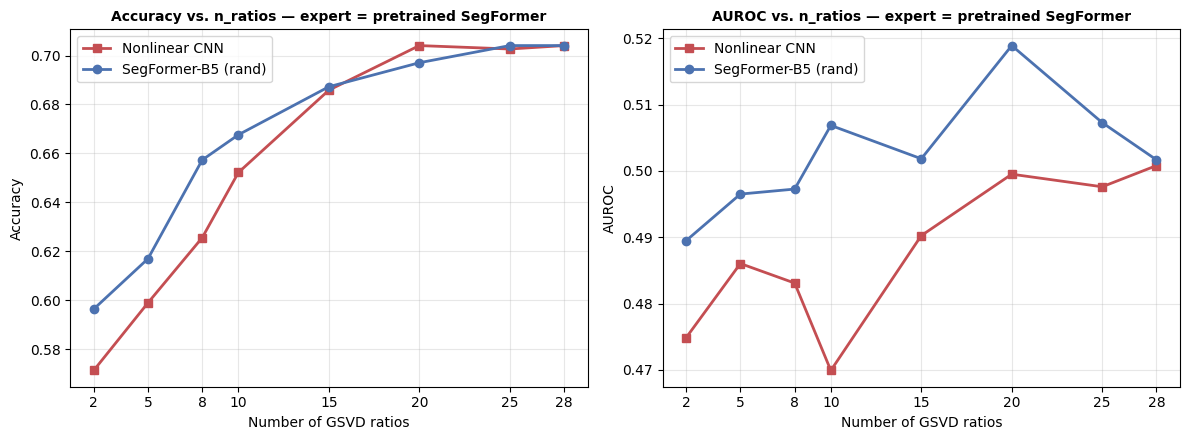

In [25]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
style_e4 = {"Nonlinear CNN":       dict(color="#C44E52", marker="s"),
            "SegFormer-B5 (rand)": dict(color="#4C72B0", marker="o")}
# This loop can take a while; when debugging I run on a tiny subset first.
for ax, key, ylabel in zip(axes, ["accuracy", "auroc"], ["Accuracy", "AUROC"]):
    for novice_name in NOVICE_CLASSES_E4:
        rows = [r for r in sweep_rows_e4 if r["novice"] == novice_name]
        ns = [r["n_ratios"] for r in rows]
        vs = [r[key] for r in rows]
        ax.plot(ns, vs, linewidth=2, markersize=6, label=novice_name, **style_e4[novice_name])
    ax.set_xlabel("Number of GSVD ratios")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs. n_ratios — expert = pretrained SegFormer",
                 fontweight="bold", fontsize=10)
    ax.set_xticks(N_RATIOS_LIST_E4)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EXP4_DIR, "nratios_sweep.pdf"), dpi=300, bbox_inches="tight")
plt.show()

Takeaway: The GSVD signal OOD method seams to benefit from a genralist expert.


## Best model: final configuration & threshold check

Okay so from the ablations the winning combo is:
- Expert: DINOv3 ViT-B/16
- Novice: Nonlinear CNN
- Aggregation: median
- Window: leading `n=10` ratios

So below we:
1. Re-use the ratios already saved in `exp23/raw_ratios.csv` (no need to recompute).
2. Build the per-image score = `median(ratios[:10])` for the Nonlinear CNN rows only.
3. Plot the ID vs OOD histogram with both thresholds (6 and 10) marked, so we can
   eyeball whether 10 is actually closer to the natural valley between the two modes.
4. Report balanced acc / precision / recall / F1 at both thresholds side-by-side.

That way when we submit to the server we can pick the threshold that generalises, not
just the one that happens to max local bal. acc.


N images: 713  |  ID: 503  OOD: 210
Score range: [1.081, 20.660]   AUROC: 0.9425


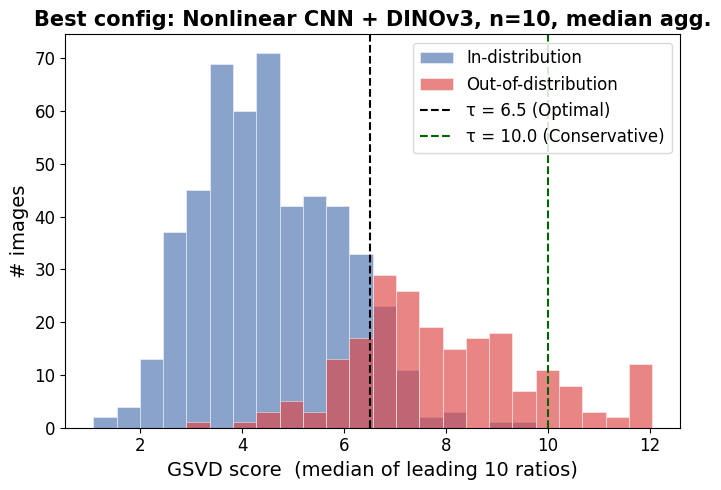

In [26]:
# =============================================================
# Best config histogram + threshold comparison
# Reuses ratios saved by run_exp23(), so no computation time :))
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

BEST_DIR  = os.path.join(RESULTS_ROOT, "best_model_nonlinear_dinov3")
os.makedirs(BEST_DIR, exist_ok=True)

BEST_NOVICE   = "Nonlinear CNN"
N_RATIOS_BEST = 10                # A3 winner
AGG           = np.median         # A1 winner

# Legend cleanup: Simplified threshold names
THRESHOLDS    = {"Optimal": 6.50,
                 "Conservative": 10.00}

# Load ratios from Exp 2/3 CSV
df = pd.read_csv(EXP23_CSV)
df = df[df["novice"] == BEST_NOVICE].reset_index(drop=True)
ratio_cols = [c for c in df.columns if c.startswith("ratio_")]

# Build GSVD score using the best config (median of leading 10 ratios)
ratios_mat = df[ratio_cols].to_numpy(dtype=float)          # (N, 64)
scores     = AGG(ratios_mat[:, :N_RATIOS_BEST], axis=1)    # (N,)
y_true     = (df["label"].values == "OOD").astype(int)     # 1 = OOD

print(f"N images: {len(scores)}  |  ID: {(y_true==0).sum()}  OOD: {(y_true==1).sum()}")
print(f"Score range: [{scores.min():.3f}, {scores.max():.3f}]   "
      f"AUROC: {roc_auc_score(y_true, scores):.4f}")

# Histogram of scores by true label
id_scores  = scores[y_true == 0]
ood_scores = scores[y_true == 1]

vis_clip = np.percentile(scores, 99)
bins = np.linspace(scores.min(), vis_clip, 25)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(np.clip(id_scores,  None, vis_clip), bins=bins, alpha=0.65, color="#4C72B0",
        label="In-distribution", edgecolor="white", linewidth=0.5)
ax.hist(np.clip(ood_scores, None, vis_clip), bins=bins, alpha=0.65, color="#DD4444",
        label="Out-of-distribution", edgecolor="white", linewidth=0.5)

colors = {"Optimal": "black", "Conservative": "darkgreen"}
# This loop can take a while; when debugging I run on a tiny subset first.
for name, t in THRESHOLDS.items():
    ax.axvline(t, color=colors[name], linestyle="--", linewidth=1.5,
               label=f"τ = {t:.1f} ({name})")

ax.set_xlabel(f"GSVD score  (median of leading {N_RATIOS_BEST} ratios)", fontsize=14)
ax.set_ylabel("# images", fontsize=14)
ax.set_title(f"Best config: {BEST_NOVICE} + DINOv3, n={N_RATIOS_BEST}, median agg.", fontweight="bold", fontsize=15)

ax.legend(fontsize=12, framealpha=0.85, edgecolor='lightgray')

ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BEST_DIR, "score_histogram.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(BEST_DIR, "score_histogram.png"), dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Save the weights of this config model for server submission
set_seed(1)
calib_novice = NonlinearNovice().to(DEVICE).eval()

weights_dir = "../weights"
os.makedirs(weights_dir, exist_ok=True)

save_path = os.path.join(weights_dir, "novice_nonlinear_seed1.pt")
torch.save(calib_novice.state_dict(), save_path)

print("Saved novice weights:", sum(p.numel() for p in calib_novice.parameters()), "params")

Saved novice weights: 1109952 params


## Visualising the GSVD subspace

1. Compute the GSVD between novice (A) and expert (B) features.
2. Take `k=2` columns of `U` and `V` starting at index `256` (the same tail window used for scoring).
4. Reshape each picked channel (length `HW = 1024`) to a `32×32` feature map and plot it next to the input image.


ID example : tubingen_000050_000019_leftImg8bit.png
OOD example: airplane0000.jpg


/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_77963/4212212252.py:24: RuntimeWarning: divide by zero encountered in divide
  return C / S
/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_77963/4212212252.py:38: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))


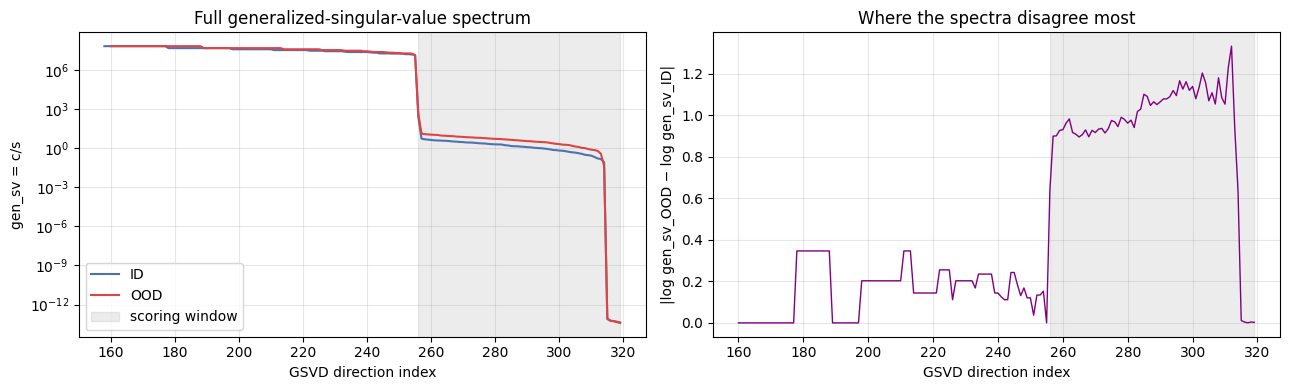

Peak disagreement index: 0  (score window: 256–319)
Using start_idx = 0 for visualization


/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_77963/4212212252.py:50: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))
/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_77963/4212212252.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.5)


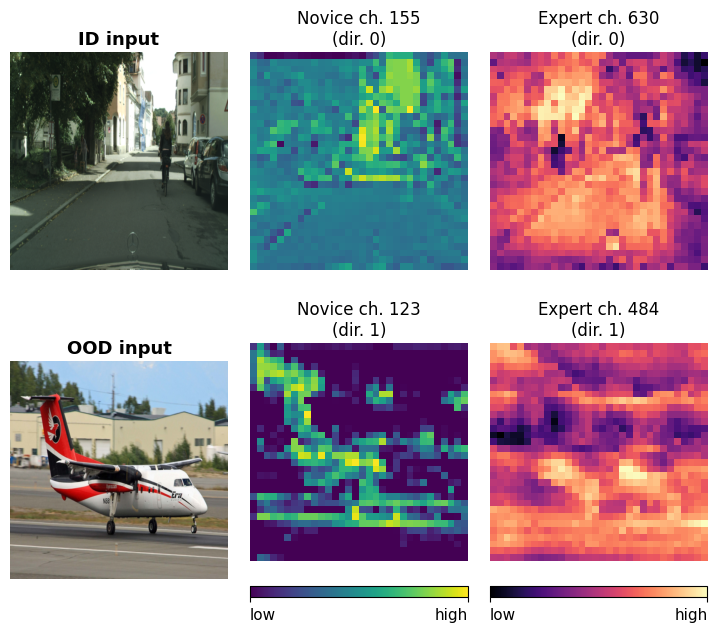

In [28]:
from numpy.linalg import solve

# Spectrum visulization where expert and novice disagree most
id_example  = collect_image_paths(ID_FOLDERS)[50]
ood_example = collect_image_paths(OOD_FOLDERS)[100]
print("ID example :", os.path.basename(id_example))
print("OOD example:", os.path.basename(ood_example))

set_seed(SEED)
novice = NonlinearNovice().to(DEVICE).eval()
expert = DinoExpert().to(DEVICE).eval()

def gen_sv_of(path):
    img = Image.open(path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        A_feat = novice(x)
        B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
    A = A_feat.squeeze(0).flatten(1).T
    B = B_feat.squeeze(0).flatten(1).T
    A_norm = F.normalize(A, dim=1).T.cpu().numpy()
    B_norm = F.normalize(B, dim=1).T.cpu().numpy()
    _, _, _, C, S = gsvd0(A_norm, B_norm)
    return C / S

gs_id  = gen_sv_of(id_example)
gs_ood = gen_sv_of(ood_example)

# Plot spectra + their difference
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(gs_id,  label="ID",  color="#4C72B0", linewidth=1.5)
axes[0].semilogy(gs_ood, label="OOD", color="#DD4444", linewidth=1.5)
axes[0].axvspan(256, 319, alpha=0.15, color="gray", label="scoring window")
axes[0].set_xlabel("GSVD direction index"); axes[0].set_ylabel("gen_sv = c/s")
axes[0].set_title("Full generalized-singular-value spectrum")
axes[0].legend(); axes[0].grid(alpha=0.3)

diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))
axes[1].plot(diff, color="purple", linewidth=1)
axes[1].axvspan(256, 319, alpha=0.15, color="gray")
axes[1].set_xlabel("GSVD direction index")
axes[1].set_ylabel("|log gen_sv_OOD − log gen_sv_ID|")
axes[1].set_title("Where the spectra disagree most")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

peak_idx = int(np.argmax(diff))
print(f"Peak disagreement index: {peak_idx}  (score window: 256–319)")

diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))
peak_idx = int(np.argmax(diff[:-3]))   # skip floor-collapse tail
print(f"Using start_idx = {peak_idx} for visualization")

def deim(U, k):
    """Discrete Empirical Interpolation Method — pick k row indices of U (shape (m, k))."""
    indices = [int(np.argmax(np.abs(U[:, 0])))]
    # This loop can take a while; when debugging I run on a tiny subset first.
    for j in range(1, k):
        c = solve(U[np.ix_(indices, range(j))], U[indices, j])
        r = U[:, j] - U[:, :j] @ c
        indices.append(int(np.argmax(np.abs(r))))
    return indices

def feats_and_gsvd(path, novice, expert):
    """Run novice + expert on one image and return GSVD pieces."""
    img = Image.open(path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        A_feat = novice(x)
        B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
    A = A_feat.squeeze(0).flatten(1).T                    # (HW, C_A)
    B = B_feat.squeeze(0).flatten(1).T                    # (HW, C_B)
    A_norm = F.normalize(A, dim=1).T.cpu().numpy()        # (C_A, HW)
    B_norm = F.normalize(B, dim=1).T.cpu().numpy()        # (C_B, HW)
    U, V, _, C, S = gsvd0(A_norm, B_norm)
    return img, A_norm, B_norm, U, V

def to_map(vec):
    """Flip sign for consistent coloring, then reshape to the 32x32 grid."""
    if vec.sum() < 0:
        vec = -vec
    return vec.reshape(32, 32)

start_idx = peak_idx
k = 2


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(2, 3, figsize=(9, 7.5),gridspec_kw={'width_ratios': [1, 1, 1],'wspace': 0.1, 'hspace': 0.15})

row_configs = [ ("ID",  id_example,  0),
("OOD", ood_example, 1),
]

for row, (label, path, dir_idx) in enumerate(row_configs):
    img, A_norm, B_norm, U, V = feats_and_gsvd(path, novice, expert)

    U_sel = U[:, start_idx:start_idx + 2]
    V_sel = V[:, start_idx:start_idx + 2]
    indU = deim(U_sel, 2)
    indV = deim(V_sel, 2)

    local = dir_idx
    a_map = to_map(A_norm[indU[local], :])
    b_map = to_map(B_norm[indV[local], :])

    # 1. Input Image
    axes[row, 0].imshow(img.resize((512, 512)))
    axes[row, 0].set_title(f"{label} input", fontweight="bold", fontsize=13)
    axes[row, 0].axis("off")

    # 2. Novice Channel
    nov_im = axes[row, 1].imshow(a_map, cmap="viridis")
    axes[row, 1].set_title(f"Novice ch. {indU[local]}\n(dir. {start_idx + local})", fontsize=12)
    axes[row, 1].axis("off")

    # 3. Expert Channel
    exp_im = axes[row, 2].imshow(b_map, cmap="magma")
    axes[row, 2].set_title(f"Expert ch. {indV[local]}\n(dir. {start_idx + local})", fontsize=12)
    axes[row, 2].axis("off")

    # Attach horizontal colorbars strictly to the bottom row
    if row == 1:
        # Novice Colorbar
        divider_nov = make_axes_locatable(axes[row, 1])
        cax_nov = divider_nov.append_axes("bottom", size="5%", pad=0.25)
        cb_n = fig.colorbar(nov_im, cax=cax_nov, orientation="horizontal")
        cb_n.set_ticks([nov_im.get_array().min(), nov_im.get_array().max()])
        cb_n.ax.set_xticklabels(["low", "high"])
        cb_n.ax.tick_params(labelsize=11)

        tick_labels_n = cb_n.ax.get_xticklabels()
        tick_labels_n[0].set_ha("left")
        tick_labels_n[-1].set_ha("right")

        # Expert Colorbar
        divider_exp = make_axes_locatable(axes[row, 2])
        cax_exp = divider_exp.append_axes("bottom", size="5%", pad=0.25)
        cb_e = fig.colorbar(exp_im, cax=cax_exp, orientation="horizontal")
        cb_e.set_ticks([exp_im.get_array().min(), exp_im.get_array().max()])
        cb_e.ax.set_xticklabels(["low", "high"])
        cb_e.ax.tick_params(labelsize=11)

        tick_labels_e = cb_e.ax.get_xticklabels()
        tick_labels_e[0].set_ha("left")
        tick_labels_e[-1].set_ha("right")

# Tight layout
plt.tight_layout(pad=1.5)

plt.savefig(os.path.join(BEST_DIR, "gsvd_feature_viz.pdf"),
            dpi=300, bbox_inches="tight")
plt.show()
del novice, expert
if DEVICE == "cuda":
    torch.cuda.empty_cache()


### Plot histogram

In [29]:

BEST_NOVICE   = "Nonlinear CNN"
N_RATIOS_BEST = 10
AGG           = np.median
# Tune this!!!
THRESHOLD     = 6.5

# Load ratios (same as histogram code)
df = pd.read_csv(EXP23_CSV)
df = df[df["novice"] == BEST_NOVICE].reset_index(drop=True)

ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
ratios_mat = df[ratio_cols].to_numpy(dtype=float)
df["score"] = AGG(ratios_mat[:, :N_RATIOS_BEST], axis=1)

# Split
id_df  = df[df["label"] == "ID"].copy()
ood_df = df[df["label"] == "OOD"].copy()

# False negatives: OOD below threshold (missed anomalies)
false_neg = ood_df[ood_df["score"] < THRESHOLD].sort_values("score")

# False positives: ID above threshold (wrongly flagged)
false_pos = id_df[id_df["score"] >= THRESHOLD].sort_values("score", ascending=False)

print(f"False negatives: {len(false_neg)} / {len(ood_df)} OOD images")
print(false_neg[["filename", "score"]].head(10).to_string(index=False))

print(f"\nFalse positives: {len(false_pos)} / {len(id_df)} ID images")
print(false_pos[["filename", "score"]].head(10).to_string(index=False))

False negatives: 37 / 210 OOD images
                                          filename    score
                                  carriage0001.jpg 3.068569
                              boat_trailer0001.jpg 3.862330
                                validation0001.jpg 4.571414
                                   tractor0004.jpg 4.667899
                                  elephant0001.jpg 4.698472
0094_13_Elly_Beinhorn_Str_000002_000090_labels.png 4.845835
0096_13_Elly_Beinhorn_Str_000003_000080_labels.png 5.030089
                                     cones0002.jpg 5.070142
                              boat_trailer0004.jpg 5.145587
0093_13_Elly_Beinhorn_Str_000002_000030_labels.png 5.181819

False positives: 44 / 503 ID images
                              filename    score
  weimar_000013_000019_leftImg8bit.png 9.647132
     ulm_000085_000019_leftImg8bit.png 9.094192
tubingen_000111_000019_leftImg8bit.png 8.145622
  weimar_000028_000019_leftImg8bit.png 7.994491
  weimar_000021_000019_lef

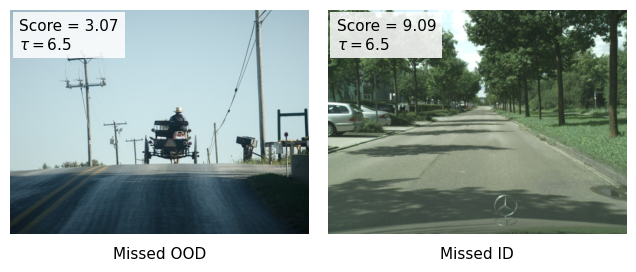

In [30]:
# Build path lookup
id_paths  = collect_image_paths(ID_FOLDERS)
ood_paths = collect_image_paths(OOD_FOLDERS)
path_lookup = {os.path.basename(p): p for p in id_paths + ood_paths}

# File names
FN_FILE = "carriage0001.jpg"
FP_FILE = "ulm_000085_000019_leftImg8bit.png"

fn_row = false_neg[false_neg["filename"] == FN_FILE].iloc[0]
fp_row = false_pos[false_pos["filename"] == FP_FILE].iloc[0]

# Adjusted figsize for a wider, more natural aspect ratio
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

cases = [
    (path_lookup[FN_FILE], fn_row["score"], "OOD", "ID", "False Positive"),
    (path_lookup[FP_FILE], fp_row["score"], "ID", "OOD", "False Negative"),
]

# This loop can take a while; when debugging I run on a tiny subset first.
for ax, (path, score, true_lbl, pred_lbl, title) in zip(axes, cases):
    img = Image.open(path).convert("RGB")

    # ImageOps.fit crops the image cleanly instead of squishing it.
    # (512, 384) gives a nice 4:3 aspect ratio that looks natural for street scenes.
    img_cropped = ImageOps.fit(img, (512, 384), centering=(0.5, 0.5))
    ax.imshow(img_cropped)

    ax.axis("off")

    # Cleaner text box without the harsh black border
    text_str = f"Score = {score:.2f}\n$\\tau = 6.5$"
    ax.text(
        0.03, 0.96, text_str,
        transform=ax.transAxes,
        fontsize=11,
        va="top", ha="left",
        bbox=dict(boxstyle="square,pad=0.4", facecolor="white", edgecolor="none", alpha=0.85)
    )

    # Bottom text moved slightly up so it feels attached to the image
    caption = f"Missed {true_lbl}"
    ax.text(
        0.5, -0.06, caption,
        transform=ax.transAxes,
        fontsize=11,
        va="top", ha="center"
    )

# Reduce the horizontal space (wspace) between the two plots
plt.subplots_adjust(wspace=0.05, bottom=0.15, top=0.85)

plt.savefig(os.path.join(BEST_DIR, "failure_cases.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(BEST_DIR, "failure_cases.png"), dpi=150, bbox_inches="tight")
plt.show()

What to look for: on the ID image, the novice and expert picked channels should look roughly similar (both models "agree" on the scene structure). On the OOD image, the expert's picked channel should light up around the anomalous object (since that's the region where the expert's structured features differ most from the random-like novice) — which is exactly what pushes the GSVD tail ratios up and drives the OOD score.
